In [2]:
from datasets import load_dataset

# Downloading the Dataset from Hugging Face Hub
emotions = load_dataset(path="dair-ai/emotion", cache_dir="../Data/emotion") # cache_dir → storing and caching loaction 

In [3]:
emotions # A Dictonary of Dataset Objects (Dataset Objects —→ Hugging Face datatype for datasets)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [4]:
train_ds = emotions["train"]
train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

In [5]:
print(len(train_ds))
print(train_ds.shape)
print(train_ds[0]) # type —→ python dict
print(train_ds.column_names)

16000
(16000, 2)
{'text': 'i didnt feel humiliated', 'label': 0}
['text', 'label']


In [6]:
type(train_ds)

datasets.arrow_dataset.Dataset

The 🤗 Datasets Object is based on [_Apache Arrow_](https://arrow.apache.org/), which defines a typed columnar format that is more memory efficient than native Python.

In [7]:
train_ds.features

{'text': Value('string'),
 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}

In [8]:
train_ds[:5] # dict of lists

{'text': ['i didnt feel humiliated',
  'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
  'im grabbing a minute to post i feel greedy wrong',
  'i am ever feeling nostalgic about the fireplace i will know that it is still on the property',
  'i am feeling grouchy'],
 'label': [0, 0, 3, 2, 3]}

In [9]:
train_ds["text"][:5]

['i didnt feel humiliated',
 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
 'im grabbing a minute to post i feel greedy wrong',
 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property',
 'i am feeling grouchy']

In [10]:
emotions['train'][0]

{'text': 'i didnt feel humiliated', 'label': 0}

In [11]:
import pandas as pd

emotions.set_format(type="pandas") # reset_format() —→ reset to default arrow dataset
df = emotions["train"][:]
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [12]:
def label_int2str(row): # int2str method
    return emotions["train"].features["label"].int2str(row) # .features["label"] —→ ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])

df["label_name"] = df["label"].apply(label_int2str)
df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


---

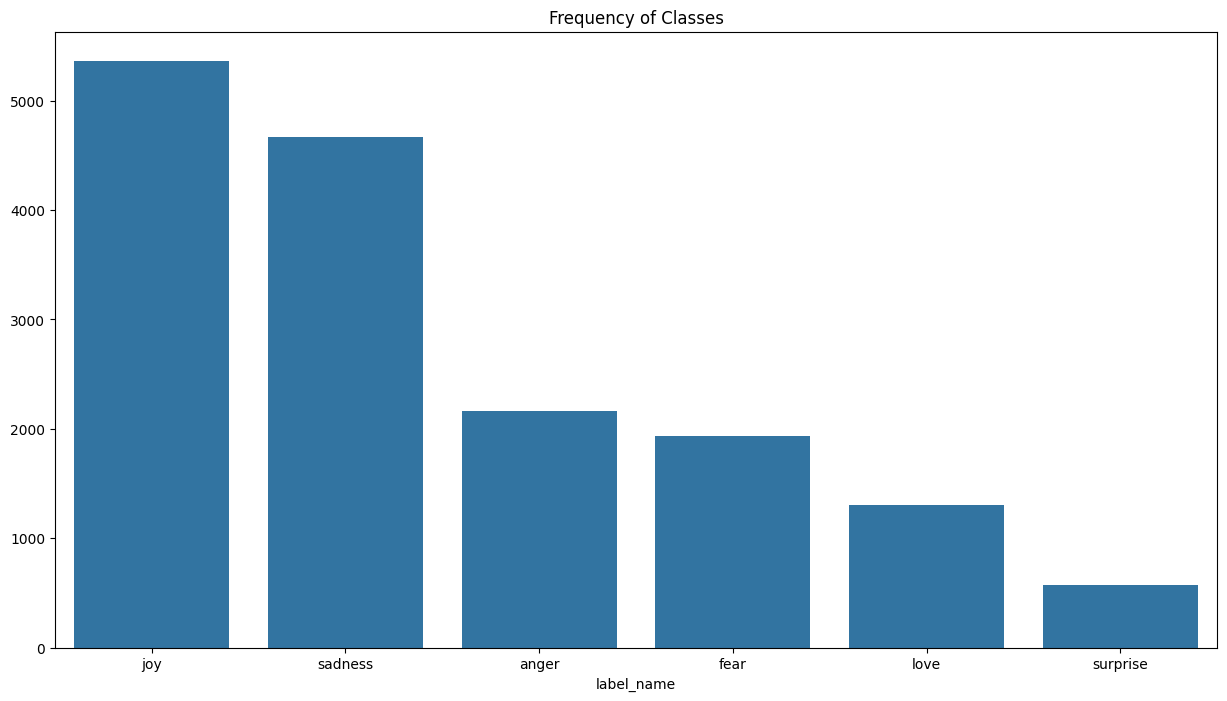

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizing the class distribution
plt.figure(figsize=(15, 8))
sns.barplot(x=df["label_name"].value_counts().index, y=df["label_name"].value_counts().values)
plt.title("Frequency of Classes")
plt.show()

Transformer models have a maximum input sequence length that is referred to as the _maximum context size_. For applications using DistilBERT, the maximum context size is `512 tokens`, which amounts to a few paragraphs of text.

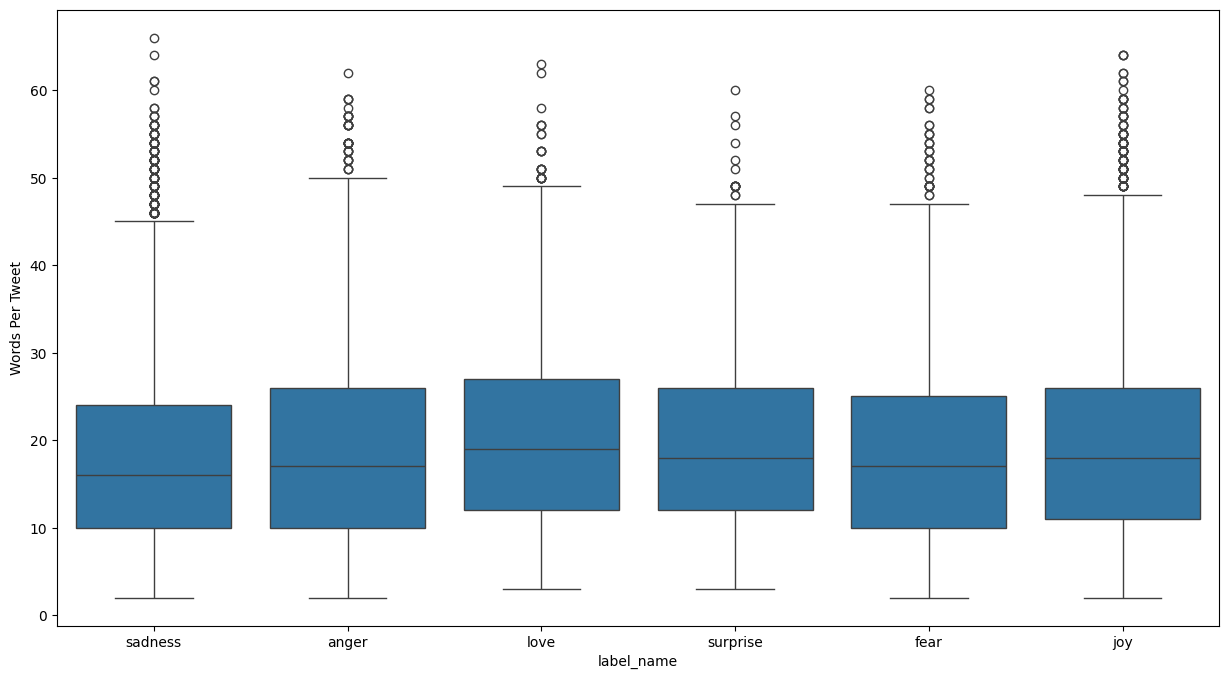

In [14]:
df["Words Per Tweet"] = df["text"].str.split().apply(len)

plt.figure(figsize=(15, 8))
sns.boxplot(data=df, x="label_name", y="Words Per Tweet")
plt.show()

# The longest tweets are well below DistilBERT's maximum context size (512 Tokens)

In [15]:
# Maximum number of tokens in a documents of the dataset —→ 66 < 512
df['text'].str.split().str.len().max()

np.int64(66)

In [16]:
emotions.reset_format()

---

In [17]:
# Character Tokenization
text = "Tokenizing text is a core task of NLP."
tokenized_text = list(text) # character tokens
print(tokenized_text)

['T', 'o', 'k', 'e', 'n', 'i', 'z', 'i', 'n', 'g', ' ', 't', 'e', 'x', 't', ' ', 'i', 's', ' ', 'a', ' ', 'c', 'o', 'r', 'e', ' ', 't', 'a', 's', 'k', ' ', 'o', 'f', ' ', 'N', 'L', 'P', '.']


In [18]:
token2idx = {ch: idx for idx, ch in enumerate(sorted(set(tokenized_text)))} # vocabulary building
print(token2idx)

{' ': 0, '.': 1, 'L': 2, 'N': 3, 'P': 4, 'T': 5, 'a': 6, 'c': 7, 'e': 8, 'f': 9, 'g': 10, 'i': 11, 'k': 12, 'n': 13, 'o': 14, 'r': 15, 's': 16, 't': 17, 'x': 18, 'z': 19}


In [19]:
input_ids = [token2idx[token] for token in tokenized_text] # tokenizing
print(input_ids)

[5, 14, 12, 8, 13, 11, 19, 11, 13, 10, 0, 17, 8, 18, 17, 0, 11, 16, 0, 6, 0, 7, 14, 15, 8, 0, 17, 6, 16, 12, 0, 14, 9, 0, 3, 2, 4, 1]


In [ ]:
# Label Encoding —→ fictitious ordering
categorical_df = pd.DataFrame(
    {"Name": ["Bumblebee", "Optimus Prime", "Megatron"], "Label ID": [0,1,2]})
categorical_df

# Incarporating order is also a pattern introduced by user (but there isn't any ordering infact). This pattern also learned by models which makes our model biased (towards anything based on application) —→ Bias through human interventions 

,Name,Label ID
0,Bumblebee,0
1,Optimus Prime,1
2,Megatron,2


In [21]:
# One Hot Encoding —→ pandas
pd.get_dummies(categorical_df["Name"]).astype(int)

,Bumblebee,Megatron,Optimus Prime
0,1,0,0
1,0,0,1
2,0,1,0


In [22]:
# One Hot Encoding —→ pytorch
import torch
import torch.nn.functional as F

input_ids = torch.tensor(input_ids)
one_hot_encodings = F.one_hot(input_ids, num_classes=len(token2idx))
one_hot_encodings.shape

torch.Size([38, 20])

In [23]:
print(f"Token: {tokenized_text[0]}")
print(f"Tensor index: {input_ids[0]}")
print(f"One-hot: {one_hot_encodings[0]}")

Token: T
Tensor index: 5
One-hot: tensor([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


In [24]:
# Word Tokenization
tokenized_text = text.split()
print(tokenized_text)

['Tokenizing', 'text', 'is', 'a', 'core', 'task', 'of', 'NLP.']


In [25]:
# Subword Tokenization
"""
    split the rare words into smaller units (character tokenization)
    split the frequent words as unique entities (word tokenization)
"""
from transformers import AutoTokenizer # Load tokenizers associated with pretrained model

model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path=model_ckpt, cache_dir="../Tokenizers/subword_tokenizer_distilbert")

The `AutoTokenizer` class belongs to a larger set of [auto classes](https://huggingface.co/docs/transformers/model_doc/auto) whose job is to automatically retrieve the model's configuration, pretrained weights, or vocabulary from the name of the checkpoint. This allows you to quickly switch between models, but if you wish to load the specific class manually you can do so as well. For example, we could have loaded the DistilBERT tokenizer as follows:

In [26]:
from transformers import DistilBertTokenizer
distilbert_tokenizer = DistilBertTokenizer.from_pretrained(model_ckpt, cache_dir="../Tokenizers/DistilBERT tokenizer/")

In [27]:
encoded_text = tokenizer(text) # tokenizing

print(text)
print(encoded_text) # attention_mask —→ tokens that represents padding encoded to 0 else 1 

tokens = tokenizer.convert_ids_to_tokens(encoded_text.input_ids) # string representations
print(tokens)

Tokenizing text is a core task of NLP.
{'input_ids': [101, 19204, 6026, 3793, 2003, 1037, 4563, 4708, 1997, 17953, 2361, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}
['[CLS]', 'token', '##izing', 'text', 'is', 'a', 'core', 'task', 'of', 'nl', '##p', '.', '[SEP]']


We can observe three things here. First, some special `[CLS]` and `[SEP]` tokens have been added to the start and end of the sequence. These tokens differ from model to model, but their main role is to indicate the start and end of a sequence. Second, the tokens have each been lowercased, which is a feature of this particular checkpoint. Finally, we can see that "tokenizing" and "NLP" have been split into two tokens, which makes sense since they are not common words. The `##` prefix in `##izing` and `##p` means that the preceding string is not whitespace (vocabulary also have `p##` like suffix tokens); any token with this prefix should be merged with the previous token when you convert the tokens back to a string.

In [28]:
print(tokenizer.convert_tokens_to_string(tokens))

[CLS] tokenizing text is a core task of nlp. [SEP]


In [29]:
tokenizer.vocab_size

30522

In [30]:
# Model context length
tokenizer.model_max_length

512

In [31]:
tokenizer.model_input_names

['input_ids', 'token_type_ids', 'attention_mask']

In [ ]:
# Tokenizing the dataset
def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True)

tokenize(emotions["train"][:2])

# This function applies the tokenizer to a batch of examples; `padding=True` will pad the examples with zeros to the size of the longest one in a batch, and `truncation=True` will truncate the documents to the maximum token sized document in tere corrosponding batch.

{'input_ids': [[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}

In [33]:
tokens2ids = list(zip(tokenizer.all_special_tokens, tokenizer.all_special_ids))
data = sorted(tokens2ids, key=lambda x : x[-1])
df = pd.DataFrame(data, columns=["Special Token", "Special Token ID"])
df.T

,0,1,2,3,4
Special Token,[PAD],[UNK],[CLS],[SEP],[MASK]
Special Token ID,0,100,101,102,103


In [34]:
# Tokenizing whole dataset with global padding
emotions_encoded = emotions.map(tokenize, batched=True, batch_size=None) # batch size —→ complete dataset (global padding)

In [35]:
emotions_encoded["train"].column_names

['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']

In [36]:
emotions_encoded.set_format(type="pandas")
emotions_encoded["train"][:].head()

,text,label,input_ids,token_type_ids,attention_mask
0,i didnt feel humiliated,0,"[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,i can go from feeling so hopeless to so damned...,0,"[101, 1045, 2064, 2175, 2013, 3110, 2061, 2062...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,im grabbing a minute to post i feel greedy wrong,3,"[101, 10047, 9775, 1037, 3371, 2000, 2695, 104...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, ..."
3,i am ever feeling nostalgic about the fireplac...,2,"[101, 1045, 2572, 2412, 3110, 16839, 9080, 128...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,i am feeling grouchy,3,"[101, 1045, 2572, 3110, 24665, 7140, 11714, 10...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, ..."


In [37]:
emotions_encoded.reset_format()

More Tokenizers → [Hugging Face Tokenizers](https://huggingface.co/docs/tokenizers/components#components) 

---

In [38]:
# Loading pre-trained model
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from transformers import AutoModel
model_ckpt = "distilbert-base-uncased"
model = AutoModel.from_pretrained(model_ckpt, cache_dir="../Models/DistilBERT/").to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


The `AutoModel` class converts the token encodings to embeddings (use lookup table), and then feeds them through the encoder stack to return the hidden states.

In [39]:
# Extracting last hidden states
text = "this is a test"

# Tokenize
inputs = tokenizer(text, return_tensors="pt")
print(f"Input tensor shape: {inputs['input_ids'].size()}")
print(inputs)

Input tensor shape: torch.Size([1, 6])
{'input_ids': tensor([[ 101, 2023, 2003, 1037, 3231,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1]])}


In [40]:
inputs = {k:v.to(device) for k,v in inputs.items()}
with torch.no_grad():
    outputs = model(**inputs) # bydefault return last hidden state
print(outputs)
print(outputs.last_hidden_state.shape) # 6 —→ [CLS], [SEP] and 4 document tokens

BaseModelOutput(last_hidden_state=tensor([[[-0.1565, -0.1862,  0.0528,  ..., -0.1188,  0.0662,  0.5470],
         [-0.3575, -0.6484, -0.0618,  ..., -0.3040,  0.3508,  0.5221],
         [-0.2772, -0.4459,  0.1818,  ..., -0.0948, -0.0076,  0.9958],
         [-0.2841, -0.3917,  0.3753,  ..., -0.2151, -0.1173,  1.0526],
         [ 0.2661, -0.5094, -0.3180,  ..., -0.4203,  0.0144, -0.2149],
         [ 0.9441,  0.0112, -0.4714,  ...,  0.1439, -0.7288, -0.1619]]],
       device='cuda:0'), hidden_states=None, attentions=None)
torch.Size([1, 6, 768])


In [41]:
outputs.last_hidden_state.size()
# The embeddings provided by DistilBERT model have dimensionality of 768D

torch.Size([1, 6, 768])

For classification tasks, it is common practice to just use the hidden state associated with the `[CLS]` token as the input feature. Since this token appears at the start of each sequence, we can extract it by simply indexing into `outputs.last_hidden_state` as follows:

In [42]:
outputs.last_hidden_state[:, 0, :].size() # 0 represents 1st token

torch.Size([1, 768])

In [43]:
def extract_hidden_states(batch):
    # Place model inputs on the GPU
    inputs = {
        k:v.to(device) for k,v in batch.items()
        if k in tokenizer.model_input_names # tokenizer.model_input_names -> ['input_ids', 'token_type_ids', 'attention_mask']
    } 

    # Extract last hidden states
    with torch.no_grad():
        last_hidden_state = model(**inputs).last_hidden_state

    # Return vector for [CLS] token
    return {"hidden_state": last_hidden_state[:, 0, :].cpu().numpy()} # Here we are appending new column as hidden_state

In [44]:
emotions_encoded.set_format("torch", columns=["input_ids", "attention_mask", "label"])

In [ ]:
emotions_hidden = emotions_encoded.map(extract_hidden_states, batched=True, batch_size=1000)

# Note that we did not set `batch_size=None` in this case, so the default `batch_size=1000` is used instead. As expected, applying the extract_hidden_states function has added a new `hidden_state` column to our dataset

In [46]:
emotions_hidden["train"].column_names

['text',
 'label',
 'input_ids',
 'token_type_ids',
 'attention_mask',
 'hidden_state']

In [47]:
emotions_hidden.set_format("pandas")
emotions_hidden["train"][:].head()

,text,label,input_ids,token_type_ids,attention_mask,hidden_state
0,i didnt feel humiliated,0,"[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.11675136, 0.09857107, -0.12962914, -0.0950..."
1,i can go from feeling so hopeless to so damned...,0,"[101, 1045, 2064, 2175, 2013, 3110, 2061, 2062...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[-0.032362908, -0.032314856, -0.19572622, -0.3..."
2,im grabbing a minute to post i feel greedy wrong,3,"[101, 10047, 9775, 1037, 3371, 2000, 2695, 104...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, ...","[0.039746452, 0.20223355, 0.14227131, -0.15119..."
3,i am ever feeling nostalgic about the fireplac...,2,"[101, 1045, 2572, 2412, 3110, 16839, 9080, 128...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[-0.032459375, 0.12369072, 0.100237735, -0.302..."
4,i am feeling grouchy,3,"[101, 1045, 2572, 3110, 24665, 7140, 11714, 10...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, ...","[-0.013516594, 0.19073103, 0.058738943, -0.270..."


In [48]:
emotions_hidden.reset_format()

In [49]:
import numpy as np

X_train = np.array(emotions_hidden["train"]["hidden_state"])
X_valid = np.array(emotions_hidden["validation"]["hidden_state"])
y_train = np.array(emotions_hidden["train"]["label"])
y_valid = np.array(emotions_hidden["validation"]["label"])

X_train.shape, X_valid.shape

((16000, 768), (2000, 768))

In [ ]:
# Training Logistic Regression model
from sklearn.linear_model import LogisticRegression 

lr_clf = LogisticRegression(max_iter=3000) # Increase `max_iter` to guarantee convergence
lr_clf.fit(X_train, y_train)

# You either use neural network as output layer or logistic regression for prediction, both are same

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",3000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [51]:
# Accuracy
lr_clf.score(X_valid, y_valid)

0.634

In [52]:
# Comparing performance of Logistic Regression against Dummy Classifier (Random Predictions)
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
dummy_clf.score(X_valid, y_valid)

0.352

So, our simple classifier with DistilBERT embeddings is significantly better than our baseline. We can further investigate the performance of the model by looking at the confusion matrix of the classifier, which tells us the relationship between the true and predicted labels:

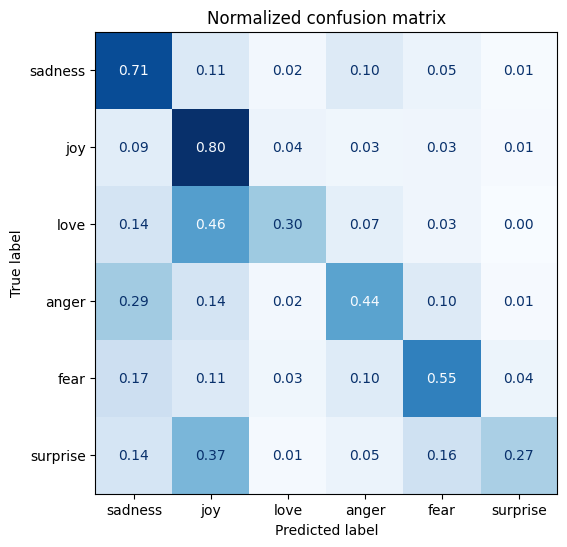

In [53]:
# Visualizing confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def plot_confusion_matrix(y_preds, y_true, labels):
    cm = confusion_matrix(y_true, y_preds, normalize="true")
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
    plt.title("Normalized confusion matrix")
    plt.show()

y_preds = lr_clf.predict(X_valid)
plot_confusion_matrix(y_preds, y_valid, labels=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])

We can see that `anger` and `fear` are most often confused with `sadness`, which agrees with the observation we made when visualizing the embeddings. Also, `love` and `surprise` are frequently mistaken for `joy`.

---

In [ ]:
# Fine Tuning
from transformers import AutoModelForSequenceClassification

num_labels = 6
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=num_labels, cache_dir="../Models/DistilBERT classifier").to(device)

# The only slight modification is that we use the `AutoModelForSequenceClassification` model instead of `AutoModel`. The difference is that the `AutoModelForSequenceClassification` model has a classification head on top of the pretrained model outputs, which can be easily trained with the base model. We just need to specify how many labels the model has to predict (six in our case), since this dictates the number of outputs the classification head has

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



To monitor metrics during training, we need to define a `compute_metrics()` function for the `Trainer`.  This function receives an `EvalPrediction` object (which is a named tuple with `predictions` and `label_ids` attributes) and needs to return a dictionary that maps each metric's name to its value. For our application, we'll compute the $F_1$-score and the accuracy of the model as follows:

In [55]:
# Performance matrics for validation
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

If you're running this code in a Jupyter notebook, you can log in to the Hub with the following helper function:

In [ ]:
from huggingface_hub import notebook_login
notebook_login(skip_if_logged_in=False) # $ huggingface-cli login —→ Terminal login
# Make sure the token have `write` permission

To define the training parameters, we use the `TrainingArguments` class. This class stores a lot of information and gives you fine-grained control over the training and evaluation. The most important argument to specify is `output_dir`, which is where all the artifacts from training are stored. Here is an example of `TrainingArguments` in all its glory:

In [58]:
from transformers import TrainingArguments

batch_size = 64
logging_steps = len(emotions_encoded["train"]) // batch_size
model_name = f"{model_ckpt}-finetuned-emotion"
training_args = TrainingArguments(
    output_dir=model_name,
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy="epoch",
    disable_tqdm=False,
    logging_steps=logging_steps,
    push_to_hub=True,
    log_level="error"
)

In [63]:
from transformers import Trainer

trainer = Trainer(
    model=model, 
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=emotions_encoded["train"],
    eval_dataset=emotions_encoded["validation"],
    processing_class=tokenizer
)

trainer.train();

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.826431,0.298347,0.916500,0.914860
2,0.245418,0.210962,0.924500,0.924367


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [64]:
preds_output = trainer.predict(emotions_encoded["validation"])

The output of the `predict()` method is a `PredictionOutput` object that contains arrays of `predictions` and `label_ids`, along with the metrics we passed to the trainer. For example, the metrics on the validation set can be accessed as follows:

In [69]:
# Logits
preds_output.predictions

array([[ 4.6571727 , -0.6400069 , -0.41116098, -0.74153566, -0.64442873,
        -1.2532643 ],
       [ 4.5471206 , -0.71305   , -1.0088563 , -0.38182822, -0.36726448,
        -1.1690304 ],
       [-1.0856075 ,  2.2620125 ,  2.8030047 , -1.1969719 , -1.6637692 ,
        -1.1321186 ],
       ...,
       [-1.3388625 ,  4.4299593 ,  0.38757   , -1.0019939 , -1.2426828 ,
        -1.1831546 ],
       [-1.5643036 ,  2.8673728 ,  2.6963904 , -1.5265257 , -1.4581455 ,
        -1.1931882 ],
       [-1.5406867 ,  4.4532576 ,  0.4032174 , -1.6607244 , -1.3618727 ,
        -0.37408152]], shape=(2000, 6), dtype=float32)

In [81]:
# Actual class labels
print(preds_output.label_ids)

# Prediction class labels
print(np.argmax(preds_output.predictions, axis=1))

[0 0 2 ... 1 1 1]
[0 0 2 ... 1 1 1]


In [72]:
# Validation metrics
preds_output.metrics

{'test_loss': 0.21096228063106537,
 'test_accuracy': 0.9245,
 'test_f1': 0.9243671692068752,
 'test_runtime': 69.2666,
 'test_samples_per_second': 28.874,
 'test_steps_per_second': 0.462}

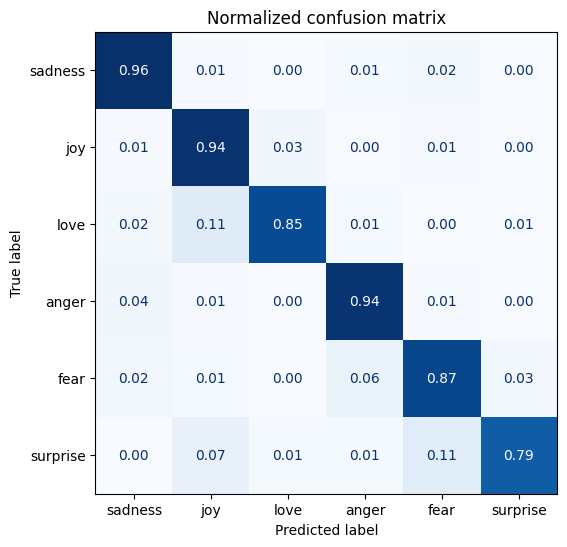

In [77]:
plot_confusion_matrix(np.argmax(preds_output.predictions, axis=1), y_valid, labels=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])

---

In [82]:
# Error Analysis
from torch.nn.functional import cross_entropy

def forward_pass_with_label(batch):
    # Place all input tensors on the same device as the model
    inputs = {k:v.to(device) for k,v in batch.items() if k in tokenizer.model_input_names}

    with torch.no_grad():
        output = model(**inputs)
        pred_label = torch.argmax(output.logits, axis=-1)
        loss = cross_entropy(output.logits, batch["label"].to(device), reduction="none")

    # Place outputs on CPU for compatibility with other dataset columns
    return {"loss": loss.cpu().numpy(), "predicted_label": pred_label.cpu().numpy()}

In [83]:
# Convert our dataset back to PyTorch tensors
emotions_encoded.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# Compute loss values
emotions_encoded["validation"] = emotions_encoded["validation"].map(forward_pass_with_label, batched=True, batch_size=16)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [86]:
emotions_encoded.set_format("pandas")
emotions_encoded['validation'][:].head()

,text,label,input_ids,token_type_ids,attention_mask,loss,predicted_label
0,im feeling quite sad and sorry for myself but ...,0,"[101, 10047, 3110, 3243, 6517, 1998, 3374, 200...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.023243,0
1,i feel like i am still looking at a blank canv...,0,"[101, 1045, 2514, 2066, 1045, 2572, 2145, 2559...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.026569,0
2,i feel like a faithful servant,2,"[101, 1045, 2514, 2066, 1037, 11633, 7947, 102...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, ...",0.501979,2
3,i am just feeling cranky and blue,3,"[101, 1045, 2572, 2074, 3110, 27987, 2100, 199...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ...",0.033911,3
4,i can have for a treat or if i am feeling festive,1,"[101, 1045, 2064, 2031, 2005, 1037, 7438, 2030...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.018972,1


In [87]:
cols = ["text", "label", "predicted_label", "loss"]
df_test = emotions_encoded["validation"][:][cols]

df_test["label"] = df_test["label"].apply(label_int2str)
df_test["predicted_label"] = (df_test["predicted_label"].apply(label_int2str))

df_test.head()

,text,label,predicted_label,loss
0,im feeling quite sad and sorry for myself but ...,sadness,sadness,0.023243
1,i feel like i am still looking at a blank canv...,sadness,sadness,0.026569
2,i feel like a faithful servant,love,love,0.501979
3,i am just feeling cranky and blue,anger,anger,0.033911
4,i can have for a treat or if i am feeling festive,joy,joy,0.018972


In [88]:
df_test.sort_values("loss", ascending=False).head(10)

,text,label,predicted_label,loss
1963,i called myself pro life and voted for perry w...,joy,sadness,5.412808
1870,i guess i feel betrayed because i admired him ...,joy,sadness,5.308383
1950,i as representative of everything thats wrong ...,surprise,anger,5.160044
1683,i had applied for a job and they had assured m...,anger,joy,4.939757
882,i feel badly about reneging on my commitment t...,love,sadness,4.932966
318,i felt ashamed of these feelings and was scare...,fear,sadness,4.867122
1274,i am going to several holiday parties and i ca...,joy,sadness,4.861375
1836,i got a very nasty electrical shock when i was...,fear,anger,4.778168
1500,i guess we would naturally feel a sense of lon...,anger,sadness,4.738741
1111,im lazy my characters fall into categories of ...,joy,fear,4.538104


In [89]:
df_test.sort_values("loss", ascending=True).head(10)

,text,label,predicted_label,loss
1873,i feel practically virtuous this month i have ...,joy,joy,0.015925
1147,i type i feel bouncy and excited to get out my...,joy,joy,0.015973
620,i shall move right along to the post interview...,joy,joy,0.016261
260,i am feeling so invigorated and so ready to ke...,joy,joy,0.016274
578,i got to christmas feeling positive about the ...,joy,joy,0.016409
856,i feel is more energetic in urban singapore th...,joy,joy,0.016606
199,i feel invigorated full of energy ready for th...,joy,joy,0.016636
19,i had lunch with an old friend and it was nice...,joy,joy,0.016736
400,i are just relaxing together and i feel ecstat...,joy,joy,0.016778
1649,i feel relieved when she goes to bed because s...,joy,joy,0.016945


In [90]:
# Saving and uploading the model on hugging face
trainer.push_to_hub(commit_message="Training completed!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/im-shriram/distilbert-base-uncased-finetuned-emotion/commit/827b5f4a3a411a9ae9527d3fa445acc1d248b13d', commit_message='Training completed!', commit_description='', oid='827b5f4a3a411a9ae9527d3fa445acc1d248b13d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/im-shriram/distilbert-base-uncased-finetuned-emotion', endpoint='https://huggingface.co', repo_type='model', repo_id='im-shriram/distilbert-base-uncased-finetuned-emotion'), pr_revision=None, pr_num=None)

In [93]:
# Loading our fine-tuned model using pipeline
from transformers import pipeline

model_id = "im-shriram/distilbert-base-uncased-finetuned-emotion"
classifier = pipeline("text-classification", model=model_id, device=device, cache_dir="../Models/Fine-Tuned DistilBERT")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
custom_tweet = "I saw a movie today and it was really bad."
preds = classifier(custom_tweet, return_all_scores=True)

In [120]:
classes = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
classes[int(preds[0]['label'][-1])]

'sadness'